Resume of the functions for HA

In [ ]:
def dkongrid(Byibx_rts, rr, nk, s_index, ntheta=102):
    """
    Takes a precomputed field array and computes d_k as a function of r 

    Parameters
    ----------
    Byibxrts : complex array, shape (nr, ntheta, ns)
        (By + i*Bx) already evaluated on the (r, theta, s) grid.
        Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — (same as dkharmonics)
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta)
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitrawcut(dkofrarray, rr, nk, nl, rmin_fit=None):
    '''
    rmin_fit: minimum r to include in the fit (to avoid blow-up of dk/r^|k| at small r).
              Defaults to rr.max() * 0.05 if not given.
    '''
    if rmin_fit is None:
        rmin_fit = rr.max() * 0.6

    mask = rr >= rmin_fit
    rr_fit = rr[mask]
    dkofr_fit = dkofrarray[mask, :]

    polynomial = np.zeros((len(rr_fit), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_fit):
        polynomial[ir, 0]    = dkofr_fit[ir, 0]
        polynomial[ir, 1::2] = dkofr_fit[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofr_fit[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_fit**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfitraw_nodiv(dkofrarray, rr, nk, nl):
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    kpos = np.arange(1, nk+1)

    # k=0: exponents are 0, 2, 4, ..., 2*(nl-1)
    V0 = np.column_stack([rr**(2*l) for l in range(nl)])
    dkl[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(kpos):
        # exponents are k, k+2, k+4, ..., k+2*(nl-1)
        V = np.column_stack([rr**(k + 2*l) for l in range(nl)])
        col_pos = 2*ik + 1
        col_neg = 2*ik + 2
        dkl[col_pos, :] = np.linalg.lstsq(V, dkofrarray[:, col_pos], rcond=None)[0]
        dkl[col_neg, :] = np.linalg.lstsq(V, dkofrarray[:, col_neg], rcond=None)[0]

    return dkl

def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):
    '''
    Like dklfitraw_nodiv but uses a Chebyshev-inspired mapped basis.
    Fits dk(r) = sum_l d_kl * T_l(u(r)) * r^k  directly, where u = scaled r^2,
    without ever dividing by r^k.

    The basis matrix for each k is:
        V[ir, l] = T_l(u(rr[ir])) * rr[ir]^k
    where T_l are Chebyshev polynomials and u = 2*(r^2 - r2min)/(r2max - r2min) - 1.

    Returns: dkl in monomial basis, shape (2*nk+1, nl).
    '''
    r0 = rr.max()
    rn = rr / r0                          # normalize to (0, 1]

    u = rn**2
    u_min, u_max = u.min(), u.max()
    u_scaled = 2 * (u - u_min) / (u_max - u_min) - 1   # in [-1, 1]

    from numpy.polynomial.chebyshev import chebvander
    T = chebvander(u_scaled, nl - 1)      # shape (nr, nl): T[ir, l] = T_l(u(rr[ir]))

    dkl = np.zeros((2*nk+1, nl), dtype=complex)

    def fit_one(y, k):
        # Basis: V[ir, l] = rn[ir]^k * T_l(u(rn[ir]))  — no division
        V = T * (rn**k)[:, None]          # shape (nr, nl)
        cheb_c, _, _, _ = np.linalg.lstsq(V, y, rcond=None)
        # cheb_c are coefficients in the T_l * r^k basis.
        # Convert the T_l part to monomials to get standard d_kl:
        mono_re = cheb2poly(cheb_c.real)
        mono_im = cheb2poly(cheb_c.imag)
        return mono_re + 1j * mono_im

    dkl[0, :] = fit_one(dkofrarray[:, 0], k=0)

    for ik, k in enumerate(np.arange(1, nk+1)):
        dkl[2*ik+1, :] = fit_one(dkofrarray[:, 2*ik+1], k=k)
        dkl[2*ik+2, :] = fit_one(dkofrarray[:, 2*ik+2], k=k)

    return dkl

def LHongrid(ByiBxongrid, s_index):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitrawcut(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn

#HA as a function of s:
def LH_s_grid(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs

On grid function

In [ ]:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitrawcut(dkofrarray, rr, nk, nl, rmin_fit=None):
    '''
    rmin_fit: minimum r to include in the fit (to avoid blow-up of dk/r^|k| at small r).
              Defaults to rr.max() * 0.6 if not given.
    '''
    if rmin_fit is None:
        rmin_fit = rr.max() * 0.6

    mask = rr >= rmin_fit
    rr_fit = rr[mask]
    dkofr_fit = dkofrarray[mask, :]

    polynomial = np.zeros((len(rr_fit), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_fit):
        polynomial[ir, 0]    = dkofr_fit[ir, 0]
        polynomial[ir, 1::2] = dkofr_fit[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofr_fit[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_fit**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfitraw_nodiv(dkofrarray, rr, nk, nl):
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    kpos = np.arange(1, nk+1)

    # k=0: exponents are 0, 2, 4, ..., 2*(nl-1)
    V0 = np.column_stack([rr**(2*l) for l in range(nl)])
    dkl[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(kpos):
        # exponents are k, k+2, k+4, ..., k+2*(nl-1)
        V = np.column_stack([rr**(k + 2*l) for l in range(nl)])
        col_pos = 2*ik + 1
        col_neg = 2*ik + 2
        dkl[col_pos, :] = np.linalg.lstsq(V, dkofrarray[:, col_pos], rcond=None)[0]
        dkl[col_neg, :] = np.linalg.lstsq(V, dkofrarray[:, col_neg], rcond=None)[0]

    return dkl
def dklfitrenormalized(dkofrarray, rr, nk, nl):#not useful
    '''
    renormalizes all r values to rref=2/3 rmax
    '''
   

    
    rr_ren = rr/rr[len(rr)*2//3]
    

    polynomial = np.zeros((len(rr_ren), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_ren):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_ren**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def dklfit_cheb(dkofrarray, rr, nk, nl):
    '''
    Same as dklfit but fits in the Chebyshev basis for better numerical stability.
    The fit variable is x = r^2, mapped to [-1, 1] for the Chebyshev domain.
    
    Returns: dkl in the MONOMIAL basis (same layout as dklfit),
             converted from Chebyshev coefficients via cheb2poly.
    '''
    polynomial = np.zeros((len(rr), 2*nk+1), dtype=complex)
    ka = np.linspace(-nk, nk, 2*nk+1)

    for ir, r in enumerate(rr):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**ka[nk+1 : 2*nk+1]
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**-ka[0: nk]

    # Map r^2 to [-1, 1] for Chebyshev domain
    x = rr**2
    x_min, x_max = x.min(), x.max()
    x_scaled = 2 * (x - x_min) / (x_max - x_min) - 1  # in [-1, 1]

    # Chebyshev Vandermonde matrix: shape (len(rr), nl)
    V = chebvander(x_scaled, nl - 1)

    # Fit all k-columns at once
    cheb_coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)
    # cheb_coeffs shape: (nl, 2*nk+1)

    # Convert each k column from Chebyshev to monomial basis
    # cheb2poly works on real arrays, so handle real/imag separately
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    for ik in range(2*nk+1):
        mono_re = cheb2poly(cheb_coeffs[:, ik].real)
        mono_im = cheb2poly(cheb_coeffs[:, ik].imag)
        dkl[ik, :] = mono_re + 1j * mono_im

    return dkl

def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):
    '''
    Numerically stable version of dklfitraw_nodiv.
    Fits dk(r) = sum_l d_kl * r^(|k|+2l) directly (no division by r^k),
    using rn = rr/rr.max() to keep basis values in (0,1].
    
    The d_kl returned are in the original (unnormalized) r basis, i.e. the r0 scaling is absorbed back into the coefficients.
    '''
    r0 = rr.max()
    rn = rr / r0    # in (0, 1]
    dkl_norm = np.zeros((2*nk+1, nl), dtype=complex)

    # k=0: basis is rn^0, rn^2, rn^4, ...
    V0 = np.column_stack([rn**(2*l) for l in range(nl)])
    dkl_norm[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(np.arange(1, nk+1)):
        V = np.column_stack([rn**(k + 2*l) for l in range(nl)])
        dkl_norm[2*ik+1, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+1], rcond=None)[0]
        dkl_norm[2*ik+2, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+2], rcond=None)[0]

    # Rescale: since rn = r/r0, rn^(k+2l) = r^(k+2l) / r0^(k+2l)
    # so d_kl_norm = d_kl * r0^(k+2l) → d_kl = d_kl_norm / r0^(k+2l)
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    dkl[0, :] = dkl_norm[0, :] / r0**(2*np.arange(nl))

    for ik, k in enumerate(np.arange(1, nk+1)):
        scale = r0**(k + 2*np.arange(nl))
        dkl[2*ik+1, :] = dkl_norm[2*ik+1, :] / scale
        dkl[2*ik+2, :] = dkl_norm[2*ik+2, :] / scale

    return dkl
#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_cut(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitrawcut(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
def LHongrid_nodiv(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn

def LH_s_grid_cut(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))
    aofs = np.zeros((len(svals), korder))
    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        aofs[i], bofs[i] = LHongrid_cut(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, aofs, bofs
def LH_s_nodiv(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid_nodiv(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs
def LH_s_nodiv_cheb(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))
    aofs = np.zeros((len(svals), korder))
    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        aofs[i], bofs[i] = LHongrid_nodiv_cheb(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, aofs, bofs


In [ ]:
#FD derivatives in midplane for comparison
def derivativesFromField(x, B_i, max_order): #i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(ss)))
    dBvector[0,:,:] = B_i[:, :] #0th derivative: take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(x_all[:,0] - 0)) #index of the x value closest to zero

dBxvector=derivativesFromField(x_all[:,0], Bx_ofx, max_order)
dByvector=derivativesFromField(x_all[:,0], By_ofx, max_order)
a_FD=np.zeros((max_order,len(ss)))
b_FD=np.zeros((len(b_coeffs),len(ss)))
a_FD[:,:]=dBxvector[:max_order,idx_zero,:]
b_FD[:,:]=dByvector[:max_order,idx_zero,:]
print("a_n from finite differences at s="+str(f"{s_fixed:.3}")+": ", a_FD[:,25] )
print("b_n from finite differences: ", b_FD[:,25] )
print("Original a_nat s="+str(f"{s_fixed:.3}")+": ", a_eva(s_fixed))
print("Original b_n: ", b_eva(s_fixed))

a_n from finite differences at s=0.282:  [-0.001  1.    -0.001  1.048]
b_n from finite differences:  [ 1.    -0.001  1.     0.   ]
Original a_nat s=0.282:  [0, 1, 0, 1]
Original b_n:  [np.float64(1.0), np.float64(0.0), np.float64(1.0), 0]


Backup momentaneo: HA non sulla grid

s fixed= 0.28205128205128194


/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


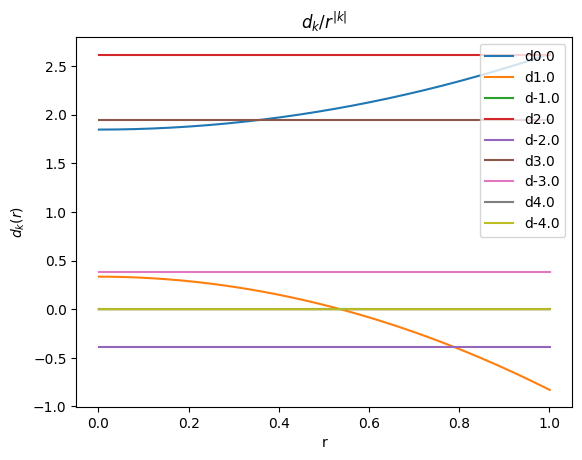

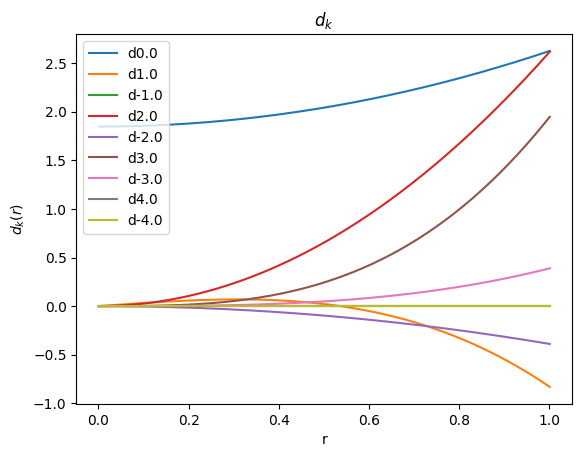

In [ ]:
def rt2xy(r,theta):
    return r*np.cos(theta), r*np.sin(theta) #cartesian positions of points on which i have the field B_func 
sindex=25
s_fixed=ss[sindex]
print("s fixed=",s_fixed)

nk=4 #maximum abs of k

def ByiBx(x, y):#analytical definition of By + i*Bx 
    return By_func(x, y,s_fixed) + 1j * Bx_func(x, y,s_fixed)
rr=np.linspace(rmin,rmax,nr)
# ByiBx=ByiBxfunc(x,y)
# theta=np.arange(ntheta)/ntheta*2*np.pi
# for r in range(rr):
#   x,y=rt2xy(r,theta)


def dkharmonics(ByiBx=ByiBx, rr=rr,nk=nk,ntheta=200): 
  '''
  returns dk as function of r 
  ''' 
  out=np.empty((len(rr),2*nk+1),dtype=complex) #prepare to store dk's as functions of r0 
  theta=np.arange(ntheta)/ntheta*2*np.pi
  for ir,r in enumerate(rr):
    x,y=rt2xy(r,theta)
    b=ByiBx(x,y)
    d=np.fft.fft(b)/ntheta #discrete fourier coefficients: dk at this r0
    out[ir,0]=d[0]#k=0
    out[ir,1::2]=d[1:nk+1] #first "fourier frequencies" are for positive k, stored in odd indexes
    out[ir,2::2]=d[ntheta:ntheta-nk-1:-1]#the last ones are for negative frequencies (take them in reverse order), stored in even indexes
  return out

dkofr=dkharmonics(rr=rr)
#plot dk(r)/r^|k|
for ki in range(2*nk+1): #plot dk(r)
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki]/rarr[:,0,sindex]**((ki+1)/2), label='d'+str((ki+1)/2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki]/rarr[:,0,sindex]**((ki)/2), label='d'+str(-ki/2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title('$d_k/r^{|k|}$')
plt.show()
#plot dk(r)
for ki in range(2*nk+1): #plot dk(r)
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str((ki+1)/2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str(-ki/2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title("$d_k$")
plt.show()



In [ ]:

def dklfit(dkofrarray,rr,nk, nl):
  '''
  takes the result from dkharmonics and fits d_k/r^|k| for different k values as a funtion of r^2l, 
  the coefficients of the fit are the values d_kl 
  parameters:
  rr=array of r values
  nk= max of |k| (not the number of different k values)
  nl= number of l values
  returns: matrix dkl
  '''
  polynomial=np.zeros((len(rr), 2*nk+1),dtype=complex)#to store d_k/r^|k|
  ka=np.linspace(-nk,nk,2*nk+1)
  for ir,r in enumerate(rr):
     polynomial[ir,0]=dkofrarray[ir,0]#for k=0 it would be divided by r0^0=1
     polynomial[ir,1::2]=dkofrarray[ir,1::2]/r**ka[nk+1 : 2*nk+1] #for positive k, odd indexes
     polynomial[ir,2::2]=dkofrarray[ir,2::2]/r**-ka[0: nk] #for negative k
  dkl=np.zeros((2*nk+1, nl), dtype=complex)#different k along rows, different l along columns
  dkl[0,:]=np.polyfit(rr**2,polynomial[:,0],deg=nl-1)[::-1] #k=0, fit r^2 since the exponent is 2l
  dkl[1::2,:]=np.polyfit(rr**2, polynomial[:,1::2], deg=nl-1)[::-1,].T #positive k
  dkl[2::2,:]=np.polyfit(rr**2, polynomial[:,2::2], deg=nl-1)[::-1,].T #negative k
  return dkl 
#alternative version
def dklfitraw(dkofrarray, rr, nk, nl):
    '''
    takes the result from dkharmonics and fits d_k/r^|k| for different k values as a function of r^2l,
    the coefficients of the fit are the values d_kl. Uses VANDERMONDE MATRIX instead of np.polyfit (faster but potentially less stable)
    parameters:
      rr    = array of r values
      nk    = max of |k| (not the number of different k values)
      nl    = number of l values
    returns: matrix dkl
    '''
    polynomial = np.zeros((len(rr), 2*nk+1), dtype=complex)
    ka = np.linspace(-nk, nk, 2*nk+1)

    for ir, r in enumerate(rr):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**ka[nk+1 : 2*nk+1]
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**-ka[0: nk]

    # Build Vandermonde matrix for r^2, degrees 0..nl-1
    x = rr**2
    V = np.vander(x, nl, increasing=True)  # shape (len(rr), nl)

    # Fit all 2*nk+1 columns at once: coeffs shape is (nl, 2*nk+1)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    # dkl[k, l] layout: rows = k index, cols = l index
    dkl = coeffs.T  # shape (2*nk+1, nl)

    return dkl


nl=nk//2+1
prdkl=dklfitraw(dkofr,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(prdkl)

#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result

bnianLHA =bnianHAopt(prdkl, nl=nl, nk=nk)
print("coeffs with my function")
print("bn=", bnianLHA.real)
print("an=", bnianLHA.imag)

coeffbpmeth=bpmeth.harmonics(ByiBx=ByiBx, nk=nk, rmin=rmin, rmax=rmax,nr=nr,ntheta=102)

bpmeth.print_harmonics(coeffbpmeth)
bnianbp = bpmeth.calc_coeffs(coeffbpmeth)
print("with bpmeth")
print("bn:", bnianbp.real)
print("an:", bnianbp.imag)

columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[  1.847+1.j      0.777+0.j     -0.   -0.j   ]
 [  0.335+2.j     -1.163+0.j      0.   -0.j   ]
 [  0.   -0.j     -0.   +0.j      0.   -0.j   ]
 [  2.612+1.5j    -0.   +0.j      0.   -0.j   ]
 [-12.624-0.j     54.299+0.j    -47.779-0.j   ]
 [  1.942+0.667j  -0.   +0.j      0.   -0.j   ]
 [  0.045+0.j      0.635-0.j     -0.316+0.j   ]
 [  0.   -0.j     -0.   +0.j      0.   -0.j   ]
 [  0.   +0.j     -0.   -0.j      0.   +0.j   ]]
coeffs with my function
bn= [  1.847   0.335 -18.471   4.947]
an= [1. 2. 3. 4.]
k  l=0                       l=1                       l=2                       
 0    1.8470583,   1.0000000    0.7765903,   0.0000000    0.0000000,   0.0000000
 1    0.3345799,   2.0000000   -1.1625915,   0.0000000    0.0000000,   0.0000000
-1    0.0000000,   2.0000000    0.0000000,   0.0000000    0.0000000,   0.0000000
 2    2.6117049,   1.5000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
-2   -0.3882951,   1.5000000    0.0000

In [ ]:
#timing
def mylocalharmonics():
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkharmonics(ByiBx=ByiBx,rr=rr,nk=nk,ntheta=102)
    dkl=dklfitraw(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn

def bpmethlocalharmonics():
    dkl=bpmeth.harmonics(ByiBx=ByiBx,nk=nk,rmin=rmin, rmax=rmax,nr=nr, ntheta=102)
    an=bpmeth.calc_coeffs(dkl).imag
    bn=bpmeth.calc_coeffs(dkl).real
    return an, bn
N=100
import timeit
mytime=timeit.timeit("mylocalharmonics()", globals=globals(), number=N)
bpmethtime=timeit.timeit("bpmethlocalharmonics()", globals=globals(), number=N)
print("my time=", mytime)
print("bpmeth time", bpmethtime)
print("relative improvement timed over", N,"repetitions: (bpmeth time - new code time)/bpmeth time =", (bpmethtime-mytime)/bpmethtime*100,"%")

my time= 11.072286961999907
bpmeth time 11.074738670999977
relative improvement timed over 100 repetitions: (bpmeth time - new code time)/bpmeth time = 0.022137849685699127 %


In [ ]:
#for specified fixed s:
def mylocharmats(ss,sindex,korder):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b at a specified longitudinal position s
    '''
    s_fixed=ss[sindex]
    def ByiBxsfixed(x, y,sfixed=s_fixed):#analytical definition of By + i*Bx at s=s_fixed
        return By_func(x, y, sfixed) + 1j * Bx_func(x, y, sfixed)
    #ByiBxfixs=ByiBxsfixed(x, y,sfixed=s_fixed) #analytical definition of By + i*Bx at s=s_fixed
    dk=dkharmonics(ByiBx=ByiBxsfixed, rr=rr,nk=korder,ntheta=102)
    dkl=dklfit(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
anats, bnats =mylocharmats(ss=ss, sindex=25, korder=nk)
print("an(s=",ss[sindex],")=", anats)
print("bn(s=",ss[sindex],")=", bnats)

an(s= 0.28205128205128194 )= [1. 2. 3. 4.]
bn(s= 0.28205128205128194 )= [  1.847   0.335 -18.471   4.947]


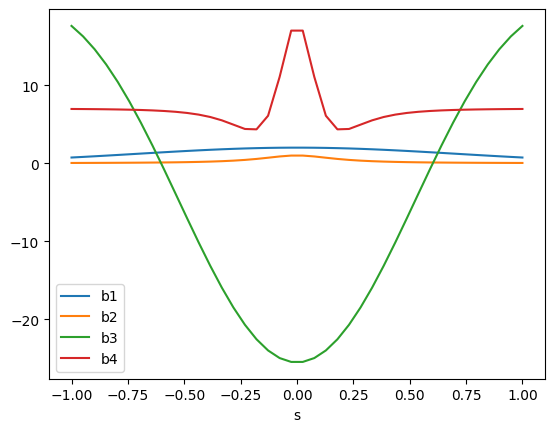

In [ ]:
#HA as a function of s:
def HAofs(ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), 4))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = mylocharmats(ss,sindex=i,korder=korder)
    
    return svals, bofs
sss, bofs = HAofs(ss=ss,korder=4)
for j in range(bofs.shape[1]):
    plt.plot(sss, bofs[:,j], label='b'+str(j+1))
plt.legend()
plt.xlabel('s')
plt.show()
         